In [1]:
# =============================================================================
# ZOOPLANKTON DATA PROCESSING
# Source: BCO-DMO CARIACO zooplankton dataset
# Bongo net tows, Mesh 200 µm and Mesh 500 µm (independent tows)
# Units: BIOMASS in mg/m³ (dry weight), ASH in mg/m³
#        All taxonomic columns in ind/m³
# =============================================================================

library(tidyverse)

# =============================================================================
# 1. READ AND CLEAN
# =============================================================================

ds <- read.csv("BCO-DMO/zooplankton.csv", na.strings = c("nd", "?"))
ds$date <- as.Date(as.character(ds$Date), format = "%Y-%m-%d")

cat("=== Raw dataset ===\n")
cat(sprintf("Rows: %d, Date range: %s to %s\n", nrow(ds), min(ds$date), max(ds$date)))
cat(sprintf("Mesh sizes: %s\n", paste(sort(unique(ds$Mesh_Size)), collapse = ", ")))

# =============================================================================
# 2. CHECK COVERAGE
#    Report NA fraction per column, separately by mesh size.
#    This determines which taxonomic columns are usable.
# =============================================================================

abundance_cols <- c("COPEPODS", "CALANOIDS", "CYCLOPOIDA", "HAPARCTICOIDA",
                    "POECILOSTOMATOIDA", "L_FISH", "H_FISH", "CHAETOGNATHA",
                    "CLADOCEROS", "OSTRACODA", "FORAMINIFERA", "AMPHIPODS",
                    "ISOPODS", "EUPHAUSIIDS", "MISYDACEA", "SERGESTID",
                    "L_CRUSTACEA", "N_COPEPOD", "C_COPEPOD", "N_CIRRIPEDIA",
                    "C_CIRRIPEDIA", "L_DECAPODA", "L_STOMATOPODA",
                    "L_EUPHAUSIID", "L_SERGESTID", "POLICHAETES",
                    "L_CYPHONAUTES", "MEDUSA", "SIPHONOPHORES", "CTENOPHORES",
                    "L_ECHINODERMS", "PTEROPODS", "HETEROPODS", "GASTROPODS",
                    "L_CEPHALOPODA", "L_BIVALVE", "L_GASTROPOD", "PROTOZOAN",
                    "RADIOLARIAN", "APPENDICULARIANS", "SALPS", "DOLIOLIDS",
                    "BIVALVES", "H_CRUSTACEA", "L_ANFIOXUS", "LUCIFER",
                    "JUV_GASTROPOD")

na_report <- ds %>%
  group_by(Mesh_Size) %>%
  summarise(
    n = n(),
    across(all_of(c("BIOMASS", "ASH", "TOTAL_DENSITY", abundance_cols)),
           ~sum(is.na(.x)) / n(), .names = "pct_na_{.col}")
  ) %>%
  pivot_longer(starts_with("pct_na_"), names_to = "variable", values_to = "pct_na") %>%
  mutate(variable = str_remove(variable, "pct_na_"))

cat("\n=== Variables with >50% NA (by mesh size) ===\n")
na_report %>%
  filter(pct_na > 0.5) %>%
  arrange(Mesh_Size, desc(pct_na)) %>%
  print(n = 50)

cat("\n=== Copepod subgroup coverage ===\n")
na_report %>%
  filter(variable %in% c("CALANOIDS", "CYCLOPOIDA", "HAPARCTICOIDA",
                          "POECILOSTOMATOIDA", "N_COPEPOD", "C_COPEPOD")) %>%
  mutate(pct_na = round(pct_na * 100, 1)) %>%
  print()

# =============================================================================
# 3. FUNCTIONAL GROUP AGGREGATION
#    Group taxa into ecologically meaningful categories.
#    Only use columns with reasonable coverage (<50% NA per mesh).
#    NAs are kept as-is — missing values in this dataset reflect
#    unmeasured or unresolved taxa, NOT below-detection zeros.
# =============================================================================

# Identify columns with acceptable coverage (< 50% NA in BOTH mesh sizes)
usable_cols <- na_report %>%
  select(Mesh_Size, variable, pct_na) %>%
  pivot_wider(names_from = Mesh_Size, values_from = pct_na) %>%
  filter(`200` < 0.5 & `500` < 0.5) %>%
  pull(variable)

cat("\n=== Usable abundance columns (< 50% NA in both meshes) ===\n")
cat(paste(usable_cols, collapse = ", "), "\n")

# Define functional groups from usable columns
# Groups follow broad ecological roles relevant to trophic cascade framing:
#   - Copepods: dominant grazers, link between phytoplankton and fish
#   - Gelatinous: alternative grazing pathway (medusae, siphonophores, ctenophores, salps, etc.)
#   - Meroplankton: larval stages (fish larvae/eggs, crustacean larvae, echinoderm larvae, etc.)
#   - Other holoplankton: chaetognaths, ostracods, pteropods, appendicularians, etc.

functional_groups <- list(
  copepods         = "COPEPODS",
  chaetognaths     = "CHAETOGNATHA",
  cladocerans      = "CLADOCEROS",
  ostracods        = "OSTRACODA",
  appendicularians = "APPENDICULARIANS",
  foraminifera     = "FORAMINIFERA",
  euphausiids      = "EUPHAUSIIDS",
  pteropods        = "PTEROPODS",
  gelatinous       = c("MEDUSA", "SIPHONOPHORES", "CTENOPHORES", "SALPS", "DOLIOLIDS"),
  meroplankton     = c("L_FISH", "H_FISH", "L_CRUSTACEA", "L_ECHINODERMS",
                        "L_BIVALVE", "L_CEPHALOPODA"),
  protozoan        = "PROTOZOAN"
)

# Keep only groups whose constituent columns are all in usable_cols
functional_groups_usable <- functional_groups %>%
  keep(~all(.x %in% usable_cols))

cat("\n=== Functional groups retained ===\n")
for (grp in names(functional_groups_usable)) {
  cat(sprintf("  %s: %s\n", grp, paste(functional_groups_usable[[grp]], collapse = " + ")))
}

# =============================================================================
# 4. COMPUTE DERIVED VARIABLES
# =============================================================================

zoo <- ds %>%
  select(date, Mesh_Size, BIOMASS, ASH, TOTAL_DENSITY,
         all_of(unique(unlist(functional_groups_usable)))) %>%
  # NAs are kept as-is (unmeasured, not zero)
  identity()

# Ash-free dry weight (organic biomass)
zoo <- zoo %>%
  mutate(AFDW = BIOMASS - ASH)

# Functional group densities
# For multi-column groups: sum constituents, but return NA if ALL are NA.
# If some but not all columns are NA, sum uses available values.
for (grp in names(functional_groups_usable)) {
  cols <- functional_groups_usable[[grp]]
  zoo[[paste0("grp_", grp)]] <- ifelse(
    rowSums(!is.na(zoo[cols])) == 0,
    NA_real_,
    rowSums(zoo[cols], na.rm = TRUE)
  )
}

# Copepod fraction of total density
zoo <- zoo %>%
  mutate(copepod_frac = ifelse(!is.na(grp_copepods) & TOTAL_DENSITY > 0,
                               grp_copepods / TOTAL_DENSITY, NA_real_))

# --- Copepod subgroups (where available) ---
# These have high NA rates but may be usable for a subset of the time series.
# Compute calanoid and cyclopoid fractions of total copepods where data exist.
copepod_subgroups <- c("CALANOIDS", "CYCLOPOIDA", "HAPARCTICOIDA", "POECILOSTOMATOIDA")

zoo <- ds %>%
  select(date, Mesh_Size, all_of(copepod_subgroups)) %>%
  right_join(zoo, by = c("date", "Mesh_Size"))

zoo <- zoo %>%
  mutate(
    calanoid_frac = ifelse(!is.na(CALANOIDS) & grp_copepods > 0,
                           CALANOIDS / grp_copepods, NA_real_),
    cyclopoid_frac = ifelse(!is.na(CYCLOPOIDA) & grp_copepods > 0,
                            CYCLOPOIDA / grp_copepods, NA_real_)
  )

# =============================================================================
# 5. DIAGNOSTICS
# =============================================================================

cat("\n=== Dataset structure ===\n")
cat(sprintf("Total samples: %d (Mesh 200: %d, Mesh 500: %d)\n",
            nrow(zoo),
            sum(zoo$Mesh_Size == 200),
            sum(zoo$Mesh_Size == 500)))
cat(sprintf("Date range: %s to %s\n", min(zoo$date), max(zoo$date)))

cat("\n=== Biomass summary by mesh (mg/m³ dry weight) ===\n")
zoo %>%
  group_by(Mesh_Size) %>%
  summarise(
    n = n(),
    biomass_mean = round(mean(BIOMASS, na.rm = TRUE), 2),
    biomass_sd   = round(sd(BIOMASS, na.rm = TRUE), 2),
    afdw_mean    = round(mean(AFDW, na.rm = TRUE), 2),
    .groups = "drop"
  ) %>%
  print()

cat("\n=== Copepod dominance ===\n")
zoo %>%
  group_by(Mesh_Size) %>%
  summarise(
    copepod_frac_mean = round(mean(copepod_frac, na.rm = TRUE), 3),
    copepod_frac_sd   = round(sd(copepod_frac, na.rm = TRUE), 3),
    .groups = "drop"
  ) %>%
  print()

cat("\n=== Copepod subgroup coverage (non-NA samples) ===\n")
zoo %>%
  group_by(Mesh_Size) %>%
  summarise(
    n_total = n(),
    n_calanoid = sum(!is.na(calanoid_frac)),
    n_cyclopoid = sum(!is.na(cyclopoid_frac)),
    .groups = "drop"
  ) %>%
  print()

cat("\n=== Monthly coverage (Mesh 200 samples per year) ===\n")
zoo %>%
  filter(Mesh_Size == 200) %>%
  mutate(year = year(date)) %>%
  count(year) %>%
  as_tibble() %>%
  print(n = 20)

# =============================================================================
# 6. PIVOT TO WIDE FORMAT FOR MERGE
#    One row per date, with columns suffixed by mesh size.
# =============================================================================

zoo_export <- zoo %>%
  select(date, Mesh_Size, BIOMASS, AFDW, TOTAL_DENSITY,
         copepod_frac, calanoid_frac, cyclopoid_frac,
         starts_with("grp_"))

zoo_wide <- zoo_export %>%
  pivot_wider(
    names_from = Mesh_Size,
    values_from = -c(date, Mesh_Size),
    names_sep = "_"
  )

cat("\n=== Export dataset ===\n")
cat(sprintf("Rows: %d, Columns: %d\n", nrow(zoo_wide), ncol(zoo_wide)))
str(zoo_wide)

# =============================================================================
# 7. SAVE
# =============================================================================

saveRDS(zoo_wide, "processed/Zoo_processed.rds")
write.csv(zoo_wide, "processed/Zoo_processed.csv", row.names = FALSE)

cat("\nSaved to processed/Zoo_processed.rds and .csv\n")

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


=== Raw dataset ===
Rows: 306, Date range: 2001-10-09 to 2017-01-12
Mesh sizes: 200, 500

=== Variables with >50% NA (by mesh size) ===
# A tibble: 0 × 4
# ℹ 4 variables: Mesh_Size <int>, n <int>, variable <chr>, pct_na <dbl>

=== Copepod subgroup coverage ===
# A tibble: 12 × 4
   Mesh_Size     n variable          pct_na
       <int> <int> <chr>              <dbl>
 1       200   153 CALANOIDS           35.9
 2       200   153 CYCLOPOIDA          35.9
 3       200   153 HAPARCTICOIDA       35.9
 4       200   153 POECILOSTOMATOIDA   35.9
 5       200   153 N_COPEPOD           35.3
 6       200   153 C_COPEPOD           35.3
 7       500   153 CALANOIDS           35.9
 8       500   153 CYCLOPOIDA          35.9
 9       500   153 HAPARCTICOIDA       35.9
10       500   153 POECILOSTOMATOIDA   35.9
11       500   153 N_COPEPOD           35.3
12       500   153 C_COPEPOD           35.3

=== Usable abundance columns (< 50% NA in both meshes) ===
BIOMASS, ASH, TOTAL_DENSITY, COPEPODS, CALAN

In [2]:
cat("\n=== Copepod subgroup data: first and last available dates ===\n")
zoo %>%
  filter(!is.na(CALANOIDS)) %>%
  group_by(Mesh_Size) %>%
  summarise(
    first_date = min(date),
    last_date  = max(date),
    n = n(),
    .groups = "drop"
  ) %>%
  print()


=== Copepod subgroup data: first and last available dates ===
# A tibble: 2 × 4
  Mesh_Size first_date last_date      n
      <int> <date>     <date>     <int>
1       200 2006-11-02 2017-01-12    98
2       500 2006-11-02 2017-01-12    98


Saved to figures/fig5b_zoo_density_geomean.png


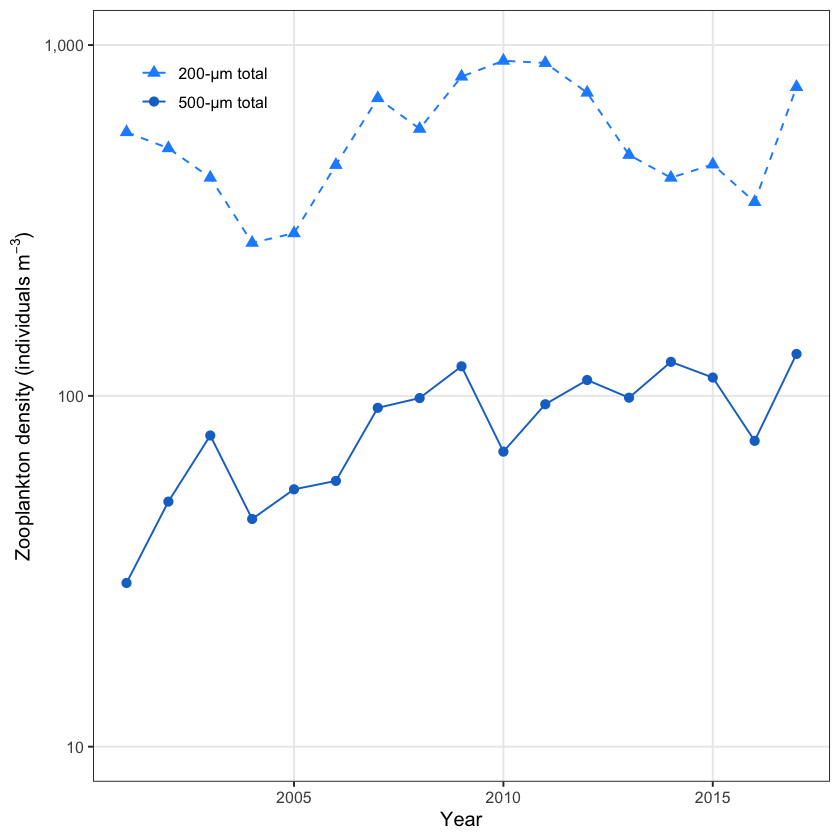

In [3]:
# =============================================================================
# Recreate Muller-Karger et al. (2019) Figure 5b
# Annual geometric mean of total zooplankton density (ind/m³)
# for 200 µm and 500 µm mesh fractions
#
# Requires: the cleaned dataset produced by the zooplankton processing script
#           (specifically the 'ds' data.frame after date parsing, or re-read raw)
# =============================================================================

library(tidyverse)

# --- Read and clean (same as processing script) ---
ds <- read.csv("BCO-DMO/zooplankton.csv", na.strings = c("nd", "?"))
ds$date <- as.Date(as.character(ds$Date), format = "%Y-%m-%d")
ds$year <- as.numeric(format(ds$date, "%Y"))

# --- Compute annual geometric means of TOTAL_DENSITY by mesh ---
annual_geomean <- ds %>%
  filter(!is.na(TOTAL_DENSITY), TOTAL_DENSITY > 0) %>%
  group_by(year, Mesh_Size) %>%
  summarise(
    n = n(),
    geomean_density = exp(mean(log(TOTAL_DENSITY))),
    .groups = "drop"
  ) %>%
  mutate(Mesh_Size = factor(Mesh_Size, levels = c(200, 500)))

# --- Plot ---
ggplot(annual_geomean, aes(x = year, y = geomean_density,
                           colour = Mesh_Size, shape = Mesh_Size,
                           linetype = Mesh_Size)) +
  geom_line() +
  geom_point(size = 2.5) +
  scale_y_log10(
    breaks = c(10, 100, 1000),
      limits=c(10,1000),
    labels = scales::comma
  ) +
  scale_colour_manual(
    values = c("200" = "dodgerblue", "500" = "dodgerblue3"),
    labels = c("200-µm total", "500-µm total")
  ) +
  scale_shape_manual(
    values = c("200" = 17, "500" = 16),
    labels = c("200-µm total", "500-µm total")
  ) +
  scale_linetype_manual(
    values = c("200" = "dashed", "500" = "solid"),
    labels = c("200-µm total", "500-µm total")
  ) +
  labs(
    x = "Year",
    y = expression("Zooplankton density (individuals m"^{-3}*")"),
    colour = NULL, shape = NULL, linetype = NULL
  ) +
  theme_bw(base_size = 12) +
  theme(
    legend.position = c(0.15, 0.90),
    legend.background = element_rect(fill = "white", colour = NA),
    panel.grid.minor = element_blank()
  )

ggsave("fig5b_zoo_density_geomean.png", width = 8, height = 4, dpi = 200)
cat("Saved to figures/fig5b_zoo_density_geomean.png\n")